In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from models.util import fit_many, fit

from models.knn import KNN
from models.decision_tree import Decision_Tree

import os

# # # Setup
os.chdir('C:\\Users\\coolt\\Desktop\\Classes\\CS 589\\HW1')

seed = 73
seed_array = np.random.randint(low=0, high=100000, size=100)

# # # Imports
wdbc = pd.read_csv('datasets\\wdbc.csv', header=None)
car = pd.read_csv('datasets\\car.csv')

In [ ]:
# # # # K Nearest Neighbors Algorithm
knn_results = []
for i in range(26): # 26
    k = 2*i + 1
    train_acc, test_acc = fit_many(data=wdbc, seeds=seed_array, model=KNN(k=k), n=20, scale=True)
    # print(np.unique(train_acc))
    # print(np.unique(test_acc))
    new_row = {'K' : k,
                        'Train_mean' : train_acc.mean(),
                        'Train_sd' : train_acc.std(),
                        'Test_mean' : test_acc.mean(),
                        'Test_sd' : test_acc.std()
            }
    knn_results.append(new_row)

knn_results = pd.DataFrame(knn_results)

KeyboardInterrupt: 

0.9650972104818258
0.011355432788232632
0.9580465587044534
0.0072547013102001595


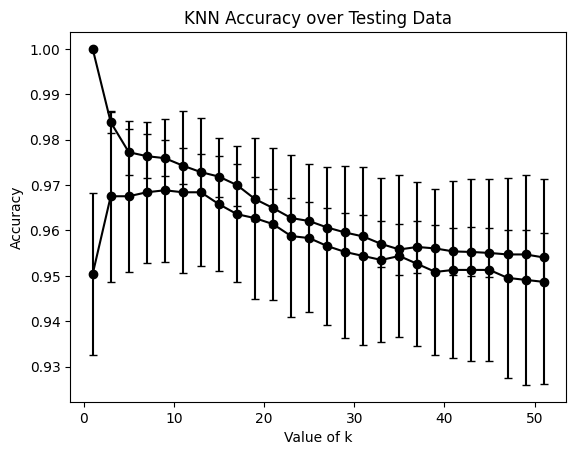

In [ ]:
# # # # KNN Plots
plt.errorbar(x=knn_results['K'], 
            y=knn_results['Train_mean'], 
            yerr=knn_results['Train_sd'],
            fmt='-o',         # Line style '-' and marker 'o'
            color='black',     # Color of the line and markers
            ecolor='black',     # Color of the error bars
            elinewidth=1.5,   # Thickness of the error bars
            capsize=3,        # Length of the error bar caps
            
    )
plt.errorbar(x=knn_results['K'], 
            y=knn_results['Test_mean'], 
            yerr=knn_results['Test_sd'],
            fmt='-o',         # Line style '-' and marker 'o'
            color='black',     # Color of the line and markers
            ecolor='black',     # Color of the error bars
            elinewidth=1.5,   # Thickness of the error bars
            capsize=3,        # Length of the error bar caps
            
    )
plt.title('KNN Accuracy over Testing Data')
plt.xlabel('Value of k')
plt.ylabel('Accuracy')
plt.show()

In [4]:
# # # # No Normalization KNN
wdbc = pd.read_csv('datasets\\wdbc.csv', header=None)

no_norm_results = []
for i in range(26): # 26
    k = 2*i + 1
    _, test_acc = fit_many(data=wdbc, seeds=seed_array, model=KNN(k=k), n=20, scale=False)
    # print(np.unique(train_acc))
    # print(np.unique(test_acc))
    new_row = {'K' : k,
                        'mean' : test_acc.mean(),
                        'sd' : test_acc.std()
            }
    no_norm_results.append(new_row)

no_norm_results = pd.DataFrame(no_norm_results)

Testing Mean:  0.9203103913630228
Testing Std Dev:  0.0018593372391549575


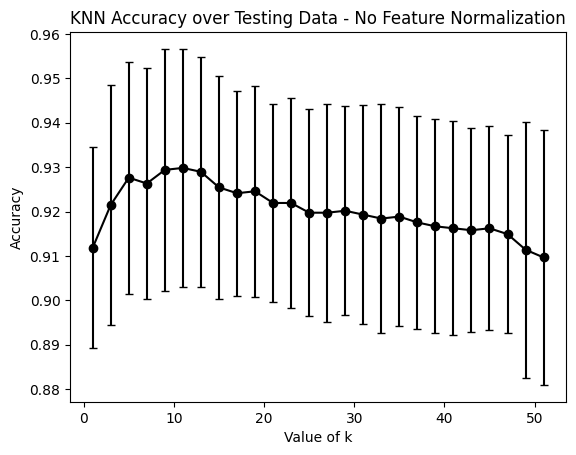

In [ ]:
# # # # No Normalization KNN Testing Plots
plt.errorbar(x=no_norm_results['K'], 
            y=no_norm_results['mean'], 
            yerr=no_norm_results['sd'],
            fmt='-o',         # Line style '-' and marker 'o'
            color='black',     # Color of the line and markers
            ecolor='black',     # Color of the error bars
            elinewidth=1.5,   # Thickness of the error bars
            capsize=3,        # Length of the error bar caps          
    )

plt.title('KNN Accuracy over Testing Data - No Feature Normalization')
plt.xlabel('Value of k')
plt.ylabel('Accuracy')
plt.show()

In [18]:
# # # # Decision Tree Algorithm

# mod = Decision_Tree(selection_method='information gain').fit(car.iloc[:,:-1], car.iloc[:,-1])
# tr, te = fit_many(car, seeds=seed_array, model=Decision_Tree(), n=100)
# res = mod.predict(car.iloc[:,:-1])

dt_train_acc, dt_test_acc = fit_many(data=car, seeds=seed_array, model=Decision_Tree(), n=100, scale=False)

1.0 0.0


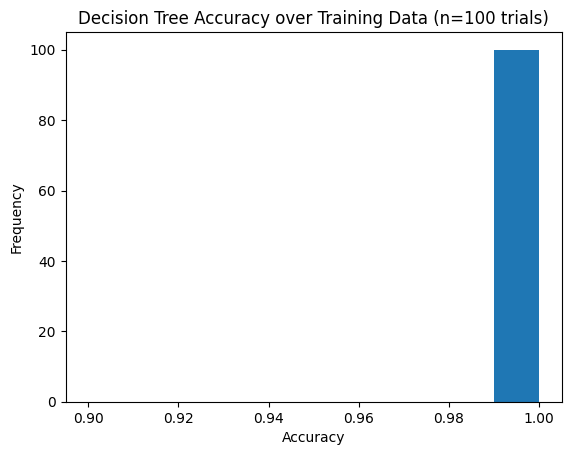

In [ ]:
# # # # Decision Tree Training Plot, Summary stats
print('Mean: ', round(dt_train_acc.mean(), 3))
print('Std Dev: ', round(dt_train_acc.std(), 3))

plt.hist(dt_train_acc, range=(.9, 1))
plt.title('Decision Tree Accuracy over Training Data (n=100 trials)')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()


Mean:  0.737
Std Dev:  0.019


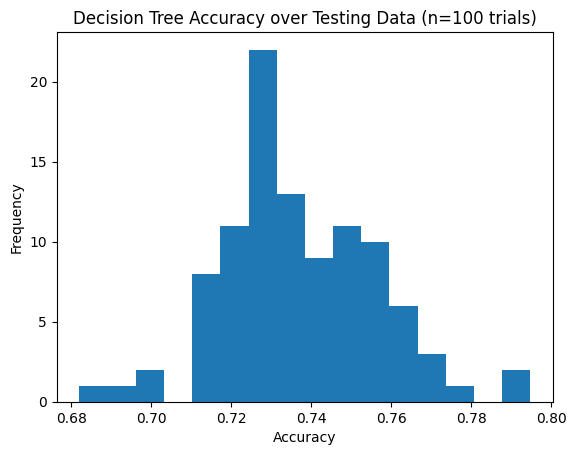

In [19]:
# # # # Decision Tree Testing Plot, Summary stats
print('Mean: ', round(dt_test_acc.mean(), 3))
print('Std Dev: ', round(dt_test_acc.std(), 3))

plt.hist(dt_test_acc, bins=16)
plt.title('Decision Tree Accuracy over Testing Data (n=100 trials)')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

In [5]:
# # # # Decision Tree - Gini Criterion
gini_train_acc, gini_test_acc = fit_many(data=car, seeds=seed_array, model=Decision_Tree(selection_method='gini'), n=100, scale=False)

In [4]:
# # # # DT Gini Criterion Training Plot, Summary Stats
print('Mean: ', round(gini_train_acc.mean(), 3))
print('Std Dev: ', round(gini_train_acc.std(), 3))

plt.hist(gini_train_acc, range=(.9, 1))
plt.title('Decision Tree Accuracy over Training Data - Gini Criterion (n=100 trials)')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

NameError: name 'gini_train_acc' is not defined

Mean:  0.828
Std Dev:  0.017


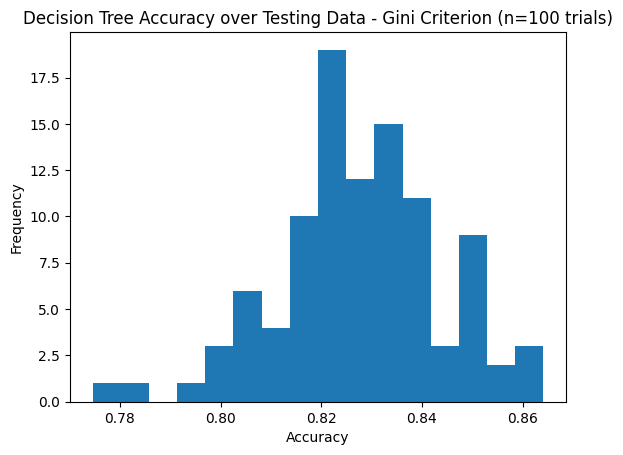

In [14]:
# # # # DT Gini Criterion Testing Plot, Summary Stats
print('Mean: ', round(gini_test_acc.mean(), 3))
print('Std Dev: ', round(gini_test_acc.std(), 3))

plt.hist(gini_test_acc, bins=16)
plt.title('Decision Tree Accuracy over Testing Data - Gini Criterion (n=100 trials)')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

In [4]:
# # # # Decision Tree - 85% stopping heuristic
stop_train_acc, stop_test_acc = fit_many(data=car, seeds=seed_array, model=Decision_Tree(majority_threshold=0.85), n=100, scale=False)

Mean:  0.998
Std Dev:  0.00618
Trials with perfect accuracy:  17


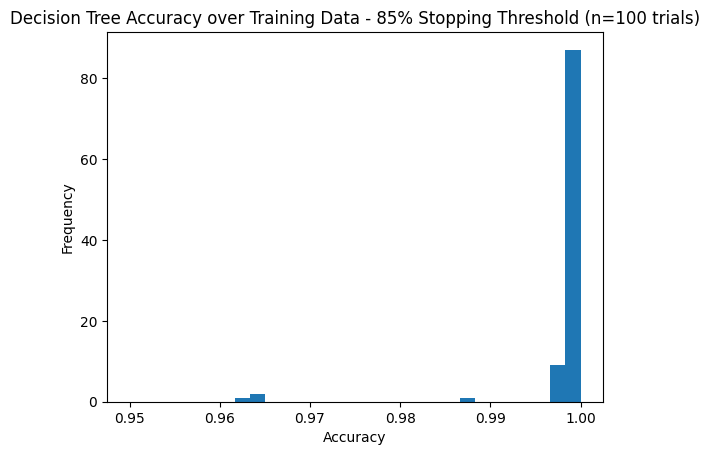

In [16]:
# # # # DT Stopping Heuristic Training Plot, Summary Stats
print('Mean: ', round(stop_train_acc.mean(), 3))
print('Std Dev: ', round(stop_train_acc.std(), 5))
print('Trials with perfect accuracy: ', (stop_train_acc == 1).sum())

plt.hist(stop_train_acc, range=(0.95, 1), bins=30)
plt.title('Decision Tree Accuracy over Training Data - 85% Stopping Threshold (n=100 trials)')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

Mean:  0.738
Std Dev:  0.01881


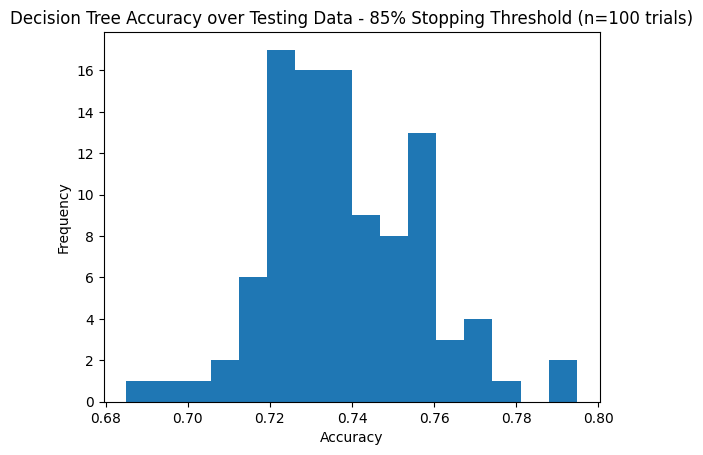

In [17]:
# # # # DT Stopping Heuristic Testing Plot, Summary Stats
print('Mean: ', round(stop_test_acc.mean(), 3))
print('Std Dev: ', round(stop_test_acc.std(), 5))

plt.hist(stop_test_acc, 16)
plt.title('Decision Tree Accuracy over Testing Data - 85% Stopping Threshold (n=100 trials)')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# # # # Decision Tree Debug
# X = car.iloc[:,:-1]
# y = car.iloc[:,-1]
# mod = Decision_Tree(majority_threshold=0.7003).fit(X, y)

# print((mod.predict(X) == y).mean())

# print(mod.decision)
# try:
#     print(mod.feature)
# except:
#     pass
    
# t1 = mod.leaves['large']
# t2 = mod.leaves['medium']
# t3 = mod.leaves['small']

# print(len(mod.data))
# print(len(t1.data))
# print(len(t2.data))
# print(len(t3.data))
# t11 = t1.leaves['high']
# t12 = t1.leaves['medium']
# t13 = t1.leaves['low']

# print([((car['luggage_boot_size'] == x) * (car['safety_level'] == 'low')).sum() for x in set(car['luggage_boot_size'])])
# print(mod.feature)
# print(t1.leaves['low'].feature)
# print(t1.leaves['medium'].feature)
# print(t1.leaves['high'].feature)
# print(t2.leaves['low'].feature)
# print(t2.leaves['medium'].feature)
# print(t2.leaves['high'].feature)
# print(t3.leaves['low'].feature)
# print(t3.leaves['medium'].feature)
# print(t3.leaves['high'].feature)

1.0
None
capacity
